In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')
here = Path.cwd()
datadir_csv = '/global/homes/b/billie/GNN_ForceInference/PersistentCells/Data_CSVs/'
#print(datadir)
datadir = '/global/homes/b/billie/GNN_ForceInference/PersistentCells/Simulations/tempXYZ/'
cmap = plt.cm.get_cmap('BuPu')
clrs=["#c7e9b4","#7fcdbb","#41b6c4","#1d91c0","#225ea8","#0c2c84","#c7e9b4","#7fcdbb","#41b6c4","#1d91c0","#225ea8","#0c2c84"]
clrs2=["#b59837","#fc8d59","#d7301f","#6f0606","#4575b4","#313695","#313695","#4575b4","#91bfdb","#313695","#4575b4","#313695","#fef0d9","#fdcc8a","#fc8d59","#d7301f","#4575b4","#313695","#313695","#4575b4","#91bfdb","#313695","#4575b4","#313695"]
clrs3=["#313695","#623CA2","#B546CE"]

Simulation definitions:

In [2]:
def parse_lammps_xyz(filename):
    data = []
    with open(filename, 'r') as file:
        while True:
            line = file.readline()
            if not line:
                break  # EOF
            
            if "ITEM: TIMESTEP" in line:
                timestep = int(file.readline().strip())
                file.readline()  # Skip "ITEM: NUMBER OF ATOMS"
                num_atoms = int(file.readline().strip())
                file.readline()  # Skip "ITEM: BOX BOUNDS ..."
                file.readline()
                file.readline()
                file.readline()
                file.readline()  # Skip "ITEM: ATOMS id type x y z"
                
                for _ in range(num_atoms):
                    atom_line = file.readline()
                    if not atom_line:
                        break  # Unexpected EOF
                    parts = atom_line.strip().split()
                    atom_id, atom_type = int(parts[0]), int(parts[1])
                    x, y, z, sumForce = map(float, parts[2:6])
                    data.append({
                        "timestep": timestep,
                        "id": atom_id,
                        "type": atom_type,
                        "x": x,
                        "y": y,
                        "z": z,
                        "sumForce": sumForce
                    })

    df = pd.DataFrame(data)
    return df

# Unwrapping the trajectories
# The function unwrap_trajectories takes a DataFrame with atom trajectories and unwraps them based on periodic boundary conditions.

def unwrap_trajectories(df, box_length_x, box_length_y):
    # Sort the DataFrame by atom ID and timestep
    df = df.sort_values(by=["id", "timestep"]).copy()

    # Group by atom ID
    unwrapped_x = []
    unwrapped_y = []

    for atom_id, group in df.groupby("id"):
        group = group.sort_values(by="timestep").copy()
        x = group["x"].values
        y = group["y"].values
        timesteps = group["timestep"].values
        if x[0]<0:
            unwrappedX = [x[0]+box_length_x]
        elif x[0]>box_length_x:
            unwrappedX = [x[0]-box_length_x]
        else:
            unwrappedX = [x[0]]
        if y[0]<0:
            unwrappedY = [y[0]+box_length_y]
        elif y[0]>box_length_y:
            unwrappedY = [y[0]-box_length_y]
        else:
            unwrappedY = [y[0]]
        
        shiftX = 0
        shiftY = 0

        for i in range(1, len(x)):
            dx = x[i] - x[i - 1]
            dy = y[i] - y[i - 1]
            if dx > box_length_x / 2:
                shiftX -= box_length_x
            if dy > box_length_y / 2:
                shiftY -= box_length_y
            elif dx < -box_length_x / 2:
                shiftX += box_length_x
            elif dy < -box_length_y / 2:
                shiftY += box_length_y
            unwrappedX.append(x[i] + shiftX)
            unwrappedY.append(y[i] + shiftY)

        unwrapped_x.extend(unwrappedX)
        unwrapped_y.extend(unwrappedY)

    df["x_unwrapped"] = unwrapped_x
    df["y_unwrapped"] = unwrapped_y
    return df

# Function to write positions to .xyz file
def write_xyz(f, positions, step,summing_forces,box_length):
    #with open(f, 'a') as f:
    f.write("ITEM: TIMESTEP\n")
    f.write(f"{step}\n")
    f.write("ITEM: NUMBER OF ATOMS\n")
    f.write(f"{len(positions)}\n")
    # Write box dimensions (optional)
    f.write("ITEM: BOX BOUNDS pp pp pp\n")
    f.write(f"{-box_length/2} {box_length/2}\n")
    f.write(f"{-box_length/2} {box_length/2}\n")
    f.write(f"0.0 0.1\n")
    f.write("ITEM: ATOMS id type x y z sumForce\n")
    i=0
    for pos in positions:
        i+=1
        f.write(f"{i} 1 {pos[0]} {pos[1]} {0} {summing_forces[i-1]}\n") 
        #f.write(f"1 {pos[0]} {pos[1]} 0.0\n")  # Assuming particles are Argon atoms
        
# Function to compute harmonic trap force (constant gradient: F = -kappa * displacement)
def harmonic_force(positions, kappa, center): 

    displacement = positions - center
    return -kappa * displacement


# Arbitrary force field: harmonic well in y, non-linear push in x (gradient is not constant)
# F_x = A_x * tanh((x - center_x) / L_x)  -> pushes in +x for x > center, saturates; dF_x/dx varies
# F_y = -kappa_y * (y - center_y)         -> harmonic well in y
def arbitrary_force(positions, kappa_y, center, A_x, L_x):
    """
    positions: (N, 2) array of (x, y)
    kappa_y: spring constant for harmonic well in y
    center: (2,) [center_x, center_y]
    A_x: strength of non-linear x-force (positive = push in +x when x > center_x)
    L_x: length scale for x force (tanh saturates over ~L_x)
    """
    x, y = positions[:, 0], positions[:, 1]
    cx, cy = center[0], center[1]
    dx = x - cx
    # Non-linear x-force: tanh gives saturation; gradient dF_x/dx = (A_x/L_x) * sech^2(dx/L_x) is not constant
    F_x = A_x * np.tanh(dx / np.maximum(L_x, 1e-10))
    F_y = -kappa_y * (y - cy)
    return np.column_stack([F_x, F_y])
    

def force_environment_NonLinear(positions, kappa_x, kappa_y, center, alpha, L):
    x, y = positions[:, 0], positions[:, 1]
    cx, cy = center[0], center[1]
    dx = x - cx
    dy = y - cy
    # alpha=1 → linear spring, alpha>1 → increasingly nonlinear
    Fx = -kappa_x * np.sign(dx) * (np.abs(dx)/L)**(alpha) * L
    Fy = -kappa_y * np.sign(dy) * (np.abs(dy)/L)**(alpha) * L
    return np.column_stack([Fx, Fy])


Simulation itself:

In [3]:
class VerletNeighborList:
    """Verlet neighbour list with skin-distance rebuild criterion."""

    def __init__(self, cutoff, skin, box_size):
        self.cutoff = float(cutoff)
        self.skin = float(skin)
        self.cutoff_with_skin = self.cutoff + self.skin
        self.rebuild_threshold = 0.5 * self.skin
        self.box_size = float(box_size)
        self.pairs = None
        self.reference_positions = None

    def _minimum_image(self, dr):
        return dr - self.box_size * np.round(dr / self.box_size)

    def needs_rebuild(self, positions):
        if self.pairs is None or self.reference_positions is None:
            return True
        displacement = self._minimum_image(positions - self.reference_positions)
        max_disp = np.max(np.linalg.norm(displacement, axis=1))
        return max_disp > self.rebuild_threshold

    def build(self, positions):
        num_particles = len(positions)
        pairs = []
        for i in range(num_particles):
            for j in range(i + 1, num_particles):
                rij = self._minimum_image(positions[i] - positions[j])
                r = np.linalg.norm(rij)
                if r < self.cutoff_with_skin:
                    pairs.append((i, j))
        self.pairs = pairs
        self.reference_positions = positions.copy()
        return pairs

    def get_pairs(self, positions):
        if self.needs_rebuild(positions):
            return self.build(positions)
        return self.pairs


def compute_soft_lj_forces(positions, box_size, epsilon, sigma, rcut, lambda_param, neighbor_pairs=None):
    n, alpha_lj = 1, 0.5
    num_particles = len(positions)
    forces = np.zeros_like(positions)
    rcut2 = rcut ** 2
    lam_pow_n = lambda_param ** n
    const_factor = 4 * epsilon * lam_pow_n
    last_force = 0.0

    if neighbor_pairs is None:
        pair_iterator = ((i, j) for i in range(num_particles) for j in range(i + 1, num_particles))
    else:
        pair_iterator = neighbor_pairs

    for i, j in pair_iterator:
        rij = positions[i] - positions[j]
        rij -= box_size * np.round(rij / box_size)
        r2 = np.dot(rij, rij)

        if r2 >= rcut2 or r2 <= 1e-12:
            continue

        r = np.sqrt(r2)
        r6 = (r / sigma) ** 6
        A = alpha_lj * (1 - lambda_param) ** 2 + r6
        dAdr = 6 * (r / sigma) ** 5 / sigma
        dEdr = const_factor * (-2 / A**3 + 1 / A**2) * dAdr
        force_vec = -dEdr * (rij / r)

        forces[i] += force_vec
        forces[j] -= force_vec
        last_force = -dEdr

    return forces, last_force

    
def compute_soft_lj_forces_vals(r, epsilon, sigma, rcut, lambda_param):
    n = 1
    alpha_lj = 0.5
    lam_pow_n = lambda_param ** n
    const_factor = 4 * epsilon * lam_pow_n
    if r >= rcut or r <= 1e-12:
        return 0.0
    r6 = (r / sigma) ** 6
    A = alpha_lj * (1 - lambda_param) ** 2 + r6
    dAdr = 6 * (r / sigma) ** 5 / sigma
    dEdr = const_factor * (-2 / A**3 + 1 / A**2) * dAdr
    
    return -dEdr

def compute_wca_wall_forces_centered(positions, box_size, epsilon, sigma, rcut=None):
    """
    Repulsive LJ (WCA) wall forces for a centered box:
      walls at x_k = ±L_k/2

    For each particle and each dimension:
      - lower wall at -L_k/2 (normal +e_k)
      - upper wall at +L_k/2 (normal -e_k)

    Args:
        positions: (N, dim)
        box_size: scalar or (dim,) array of box lengths L_k
        epsilon, sigma: WCA parameters
        rcut: optional cutoff; if None uses r_wca = 2^(1/6) * sigma

    Returns:
        forces: (N, dim)
        last_force: scalar magnitude of the last wall force applied
    """
    pos = np.asarray(positions, dtype=float)
    N, dim = pos.shape

    L = np.asarray(box_size, dtype=float)
    if L.ndim == 0:
        L = np.full(dim, float(L))

    r_wca = (2.0 ** (1.0 / 6.0)) * sigma
    rcut_eff = r_wca if rcut is None else min(float(rcut), r_wca)
    rcut2 = rcut_eff * rcut_eff

    forces = np.zeros_like(pos)
    last_force = 0.0

    for i in range(N):
        for k in range(dim):
            x = pos[i, k]
            halfL = 0.5 * L[k]

            # distance to lower wall at -L/2
            d = x + halfL          # positive inside box
            if d > 1e-12 and d * d < rcut2:
                inv_d2 = 1.0 / (d * d)
                sd2 = (sigma * sigma) * inv_d2
                sd6 = sd2 * sd2 * sd2
                sd12 = sd6 * sd6
                fmag = 24.0 * epsilon * (2.0 * sd12 - sd6) / d
                forces[i, k] += fmag
                last_force = abs(fmag)

            # distance to upper wall at +L/2
            d = halfL - x
            if d > 1e-12 and d * d < rcut2:
                inv_d2 = 1.0 / (d * d)
                sd2 = (sigma * sigma) * inv_d2
                sd6 = sd2 * sd2 * sd2
                sd12 = sd6 * sd6
                fmag = 24.0 * epsilon * (2.0 * sd12 - sd6) / d
                forces[i, k] -= fmag
                last_force = abs(fmag)

    return forces, last_force



def place_particles_in_box_crystal(num_particles, box_size, delta):
    """
    Place particles on a 2D square crystal lattice inside a square box,
    keeping all particles at least `delta` away from the walls.

    Box: [0, L] x [0, L]

    Args:
        num_particles: int
        box_size: float (L)
        delta: float (minimum distance from walls)

    Returns:
        positions: (N, 2) array
    """
    # number of lattice points per side
    n_side = int(np.ceil(np.sqrt(num_particles)))

    # usable length after wall exclusion
    L_eff = box_size - 2.0 * delta
    if L_eff <= 0:
        raise ValueError("delta is too large for the box")

    spacing = L_eff / n_side

    if spacing <= 0:
        raise ValueError("Particles do not fit with the given delta")

    positions = np.zeros((num_particles, 2))

    idx = 0
    for i in range(n_side):
        for j in range(n_side):
            if idx >= num_particles:
                break
            positions[idx] = np.array([
                delta + (i + 0.5) * spacing-box_size/2,
                delta + (j + 0.5) * spacing-box_size/2
            ])
            idx += 1

    return positions


def OD_MD_SimulationLJPairs(num_particles, box_size, kappa, temperature, gamma, dt,
                     num_steps0, equilibration_steps, frame, use_harmonic_trap,
                     name, center, epsilon, sigma, rcut, lambda_param,
                     use_neighbor_list=False, neighbor_skin=1.0,
                     collect_trajectory=False, random_seed=None, walls = False,tau=100,
                     use_arbitrary_trap=False, kappa_y=None, A_x=1.0, L_x=1.0,alpha=1):
    rng = np.random.default_rng(random_seed)
    #positions = rng.uniform(-box_size / 2, box_size / 2, size=(num_particles, 2))
    positions = place_particles_in_box_crystal(num_particles, box_size,1)
    summing_forces = np.zeros(num_particles)
    f_active = np.zeros((num_particles,2))

    num_steps = num_steps0 + equilibration_steps
    min_ljForce = 0.0

    neighbor_list = None
    if use_neighbor_list:
        neighbor_list = VerletNeighborList(sigma*2+1, neighbor_skin, box_size)

    trajectories = [positions.copy()] if collect_trajectory else None

    output_handle = None
    output_path = None
    if name:
        output_path = datadir  + name
        output_handle = open(output_path, 'w')
        
    #write_xyz(output_handle, positions, 0, summing_forces,box_size)

    for step in range(num_steps):
        if step % 100 == 0:
            print(f"Step {step}/{num_steps}")

        noise = rng.normal(0, np.sqrt(2 * temperature * gamma / dt), size=(num_particles, 2))
        


        # neighbor_pairs = None
        # if neighbor_list is not None:
        #     neighbor_pairs = neighbor_list.get_pairs(positions)

        # lj_force, scalarFLJ = compute_soft_lj_forces(
        #     positions, box_size, epsilon, sigma, rcut, lambda_param, neighbor_pairs=neighbor_pairs
        # )
        wall_force, scalarFwall = compute_wca_wall_forces_centered(positions, box_size, 500, sigma, rcut=None)

        
        # if scalarFLJ < min_ljForce:
        #     min_ljForce = scalarFLJ
        if use_harmonic_trap:     # or step < equilibration_steps
            trap_force = harmonic_force(positions, kappa, center)
        elif use_arbitrary_trap:        
            # Arbitrary field: harmonic well in y, non-linear push in x (gradient not constant)
            L=1
            trap_force = force_environment_NonLinear(positions, kappa, kappa, center, alpha, L) #arbitrary_force(positions, kappa_y or kappa, center, A_x, L_x)
        else:
            trap_force = 0

        f_active += (-f_active/tau + noise) * dt
        positions += (trap_force + f_active  + wall_force) * dt / gamma #+ wall_force lj_force + lj_force
        
       # print("Trap force magnitude",np.max(np.sqrt(trap_force[:,0]**2+trap_force[:,1]**2))) #, "active force magnitude",np.max(np.sqrt(f_active[:,0]**2+f_active[:,1]**2)))

        #print("Dimension of lj force",np.shape(lj_force))
        #print("Dimension of trap force",np.shape(trap_force))
        forces_x = f_active[:,0] / gamma # force times mobility matrix (in units of speed)
        forces_y = f_active[:,1] / gamma # force times mobility matrix (in units of speed)
        summing_forces = forces_x**2 + forces_y**2
        #print("Dimensions of summing_forces",summing_forces.shape)

        # if walls:
        #     # reject this step if it is outside the walls
        #     if positions_new[0,0] < 0 or positions_new[0,0] > box_size or positions_new[0,1] < 0 or positions_new[0,1] > box_size:
        #         positions_new = positions.copy()
        #
        #alert if we have crossed the walls
        if np.any(positions < -box_size/2) or np.any(positions > box_size/2):
            print("Alert: Particles have crossed the walls")

        positions = (positions + box_size / 2) % box_size - box_size / 2


        if collect_trajectory:
            trajectories.append(positions.copy())

        if output_handle and step % frame == 0 and step > equilibration_steps:
            write_xyz(output_handle, positions, step,summing_forces, box_size)

    if output_handle:
        output_handle.close()
        print("Simulation completed. Output written to " + name)
    else:
        print("Simulation completed.")
    print("Minimum force " + str(min_ljForce)+"for params eps"+str(epsilon)+" sig"+str(sigma)+" rc"+str(rcut))

    if collect_trajectory:
        return np.array(trajectories)
    return None



In [4]:
## Standard Parameters
folder = "/PersistentHarmonic/"
#folder = "/WithPairwise/"
folder = "/NonLinearForce_Fixed/"
kappas_ = [0.2] #[0.5,0.75,1.0,1.25,1.5,1.75,2.0] #[0.1,1.0,2.0,5.0] 0.5,1.0,1.5,1.0  
gammas_ = [1,2,5,8]
tau_mems = [3,7,12]
tau_mems = [1.0,3.0,5.0,10.0,15.0,20.0]  #[0.5,1.0,2,3,5,7,10,12,15] #[2,3,5,7,10,12,15]
#kappa = 0.5
#kappas_ = [0.5] #[0.1,0.2,0.3,0.5,1.0] #[0.1,0.2,0.5,1.0]
tau0 = 10
gamma0 = 1
seed = 0
A_x=0.5
L_x=5.0
kappa=0.3
kappas_=[0.05,0.1,0.3,0.5,1.0,2.0]
epsilon=0.0
#epsilons_ = [0.3]
alpha =1.5
alphas_ = [1,1.1,1.3,1.5,2.0,2.5] #,1.3,2.0,2.5] #1.1,1.5,2.0,3.0
NumFrames_ = [10,50,100,600]
kappa=0.5
tau0=10
for s in range(3):
    seed=1+s
    #for epsilon in epsilons_:
    #for gamma0 in gammas_:
    #for tau0 in tau_mems:
    #for alpha in alphas_:
    #for kappa in kappas_:
    for numFrames in NumFrames_:
        #epsilon = 0.0 #1.0 #0.5 #0.5
        sigma = 1.1 #+ee*0.5
        lambda_param = 0.1 #1.0
        use_harmonic_trap = False #False #True #True #False #False # Set to False to disable the trap
        use_arbitrary_trap = True #True #True #False #True #False # Set to False to disable the trap
        #kappa = 0.5  # Spring constant for the harmonic trap
        Center = np.array([0,0]) #Center of harmonic trap
        num_particles = 100
        box_size = 100  # Box is a cube of size box_size x box_size
        temperature = 0.1 #0.01 for easily inferring forces
        #gamma = 1 # Friction coefficient
        dt = 0.001  # Time step
        frame = 100 #100
        #tau = 10
        num_steps = frame*numFrames #2700 #3800 #Number of simulation steps
        equilibration_steps = 40000 #Steps to equilibrate
        rcut= sigma*2+1 #
        neighbor_skin = 0.5
        #name_anchor="output_PersistentKappas_alpha"+str(alpha)+"_box_size"+str(box_size)+"_epsilon"+str(epsilon)+"_frame"+str(frame)+"kappa"+str(kappa)+"_Gamma"+str(gamma0)+"_Tau"+str(tau0)+"Sig"+str(sigma)+"N"+str(num_particles)+"seed"+str(seed)+"_Temp"+str(temperature)+"_NumFrames"+str(int(num_steps/frame))
        name_anchor="output_PersistentFrames_alpha"+str(alpha)+"_box_size"+str(box_size)+"_epsilon"+str(epsilon)+"_frame"+str(frame)+"kappa"+str(kappa)+"_Gamma"+str(gamma0)+"_Tau"+str(tau0)+"Sig"+str(sigma)+"N"+str(num_particles)+"seed"+str(seed)+"_Temp"+str(temperature)+"_NumFrames"+str(int(num_steps/frame))
        #name_anchor="output_PersistentAndPairwise_epsilon"+str(epsilon)+"_kappa"+str(kappa)+"_Gamma"+str(gamma0)+"_Tau"+str(tau0)+"Sig"+str(sigma)+"N"+str(num_particles)+"seed"+str(seed)+"_Temp"+str(temperature)+"_NumFrames"+str(int(num_steps/frame))
        #name_anchor="output_Persistent_Arbitrap_frame"+str(frame)+"kappa"+str(kappa)+"_Gamma"+str(gamma0)+"_Tau"+str(tau0)+"Sig"+str(sigma)+"N"+str(num_particles)+"seed"+str(seed)+"_Temp"+str(temperature)+"_NumFrames"+str(int(num_steps/frame))
        #name_anchor="output_Persistent_kappa"+str(kappa)+"_Gamma"+str(gamma0)+"_Tau"+str(tau0)+"Sig"+str(sigma)+"N"+str(num_particles)+"seed"+str(seed)+"_Temp"+str(temperature)+"_NumFrames"+str(int(num_steps/frame))
        name = name_anchor+".xyz"
        # running the simulation:
        OD_MD_SimulationLJPairs(
            num_particles, box_size, kappa, temperature, gamma0, dt,
            num_steps, equilibration_steps, frame, use_harmonic_trap,
            name, Center, epsilon, sigma, rcut, lambda_param,
            use_neighbor_list=True, neighbor_skin=neighbor_skin,
            random_seed=seed, walls = True,tau = tau0, use_arbitrary_trap=use_arbitrary_trap, kappa_y=kappa, A_x=A_x, L_x=L_x,alpha = alpha
        )
        df_atoms = parse_lammps_xyz(datadir + name)
        df_save =  df_atoms.rename(columns={'id': 'particle'})
        df_save = df_save.rename(columns={'timestep': 'frame'})
        # re-name frames to be 0,1,2,3...
        df_save['frame'] = df_save['frame'].astype(int)
        # take off min frame number
        df_save['frame'] = df_save['frame'] - df_save['frame'].min()
        # divide by frame rate

        df_save['frame'] = df_save['frame'] / frame
        dataname =  name_anchor+".csv"
        df_save.to_csv(datadir_csv + folder + dataname, index=False)


Step 0/41000
Step 100/41000
Step 200/41000
Step 300/41000
Step 400/41000
Step 500/41000
Step 600/41000
Step 700/41000
Step 800/41000
Step 900/41000
Step 1000/41000
Step 1100/41000
Step 1200/41000
Step 1300/41000
Step 1400/41000
Step 1500/41000
Step 1600/41000
Step 1700/41000
Step 1800/41000
Step 1900/41000
Step 2000/41000
Step 2100/41000
Step 2200/41000
Step 2300/41000
Step 2400/41000
Step 2500/41000
Step 2600/41000
Step 2700/41000
Step 2800/41000
Step 2900/41000
Step 3000/41000
Step 3100/41000
Step 3200/41000
Step 3300/41000
Step 3400/41000
Step 3500/41000
Step 3600/41000
Step 3700/41000
Step 3800/41000
Step 3900/41000
Step 4000/41000
Step 4100/41000
Step 4200/41000
Step 4300/41000
Step 4400/41000
Step 4500/41000
Step 4600/41000
Step 4700/41000
Step 4800/41000
Step 4900/41000
Step 5000/41000
Step 5100/41000
Step 5200/41000
Step 5300/41000
Step 5400/41000
Step 5500/41000
Step 5600/41000
Step 5700/41000
Step 5800/41000
Step 5900/41000
Step 6000/41000
Step 6100/41000
Step 6200/41000
Step

KeyboardInterrupt: 

  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array
  alpha: scalar or None
  animated: bool
  backgroundcolor: color
  bbox: dict with properties for `.patches.FancyBboxPatch`
  clip_box: `.Bbox`
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: color
  figure: `.Figure`
  fontfamily or family: {FONTNAME, 'serif', 'sans-serif', 'cursive', 'fantasy', 'monospace'}
  fontproperties or font or font_properties: `.font_manager.FontProperties` or `str` or `pathlib.Path`
  fontsize or size: float or {'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}
  fontstretch or stretch: {a numeric value in range 0-1000, 'ultra-condensed', 'extra-condensed', 'condensed', 'semi-condensed', 'normal', 'semi-expanded', 'expanded', 'extra-expanded', 'ultra-expanded'}
  fontstyle or style: {'normal', 'italic', 'oblique'}
  fontvariant or variant: {'normal', 'small-caps'}
  fontweight or weight: {a

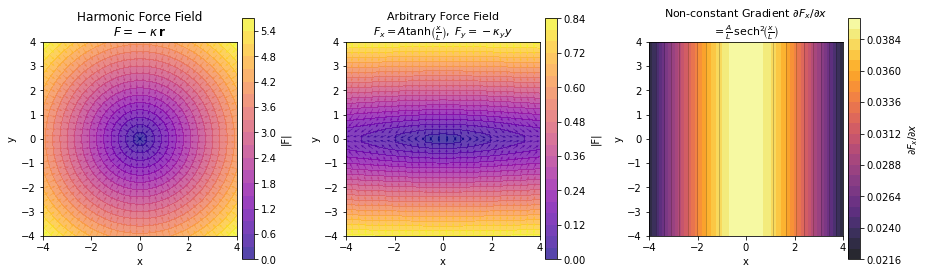

Saved → force_field.png


In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Force definitions ──────────────────────────────────────────────────────────

def harmonic_force(positions, kappa, center):
    displacement = positions - center
    return -kappa * displacement


def arbitrary_force(positions, kappa_y, center, A_x, L_x):
    """
    Arbitrary force field:
      F_x = A_x * tanh((x - cx) / L_x)   — non-linear push in x, saturates far from center
      F_y = -kappa_y * (y - cy)           — harmonic well in y

    Gradient:
      dF_x/dx = (A_x / L_x) * sech²((x-cx)/L_x)   ← spatially varying, NOT constant
      dF_y/dy = -kappa_y                            ← constant spring
    """
    x, y = positions[:, 0], positions[:, 1]
    cx, cy = center[0], center[1]
    dx = x - cx
    F_x = A_x * np.tanh(dx / np.maximum(L_x, 1e-10))
    F_y = -kappa_y * (y - cy)
    return np.column_stack([F_x, F_y])


# ── Grid setup ─────────────────────────────────────────────────────────────────

N = 30                          # grid resolution per axis
xs = np.linspace(-4, 4, N)
ys = np.linspace(-4, 4, N)
XX, YY = np.meshgrid(xs, ys)
positions = np.column_stack([XX.ravel(), YY.ravel()])

# Parameters
center  = np.array([0.0, 0.0])
kappa_y = kappa  # length scale for tanh in x

# ── Evaluate forces ────────────────────────────────────────────────────────────

F_harm = harmonic_force(positions, kappa=1.0, center=center)
F_arb  = arbitrary_force(positions, kappa_y=kappa_y, center=center, A_x=A_x, L_x=L_x)

def reshape(F):
    return F[:, 0].reshape(N, N), F[:, 1].reshape(N, N)

Fhx, Fhy = reshape(F_harm)
Fax, Fay = reshape(F_arb)

# Magnitude for colour coding
mag_harm = np.sqrt(Fhx**2 + Fhy**2)
mag_arb  = np.sqrt(Fax**2 + Fay**2)

# Normalise arrows so all are the same length (colour carries magnitude)
def norm_uv(Fu, Fv):
    mag = np.sqrt(Fu**2 + Fv**2)
    mag = np.where(mag == 0, 1, mag)
    return Fu / mag, Fv / mag

Uhx, Uhy = norm_uv(Fhx, Fhy)
Uax, Uay = norm_uv(Fax, Fay)

# ── Gradient magnitude of dFx/dx for the arbitrary field ──────────────────────
# dF_x/dx = (A_x / L_x) * sech²(dx / L_x)
dx_grid = XX - center[0]
grad_Fx = (A_x / L_x) / np.cosh(dx_grid / L_x)**2   # sech²

# ── Potential energy wells (for streamline / contour backdrop) ─────────────────
# Harmonic: U = 0.5*kappa*(x²+y²)
U_harm = 0.5 * 1.0 * (XX**2 + YY**2)
# Arbitrary: U_y = 0.5*kappa_y*y²,  U_x = -A_x*L_x*ln(cosh(dx/L_x))
dy_grid = YY - center[1]
U_arb  = 0.5 * kappa_y * dy_grid**2 - A_x * L_x * np.log(np.cosh(dx_grid / L_x) + 1e-30)

# ── Figure ─────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
# fig.patch.set_facecolor('#0f0f1a')
# for ax in axes:
#     ax.set_facecolor('#0f0f1a')
#     ax.tick_params(colors='#ccccdd')
#     for spine in ax.spines.values():
#         spine.set_edgecolor('#444455')

cmap_force = 'plasma'
cmap_grad  = 'inferno'

# ── Panel 1: Harmonic force field ─────────────────────────────────────────────
ax = axes[0]
cf = ax.contourf(XX, YY, mag_harm, levels=20, cmap=cmap_force, alpha=0.75)
ax.quiver(XX, YY, Uhx, Uhy, mag_harm, cmap=cmap_force,
          scale=30, width=0.003, headwidth=4, headlength=5, alpha=0.95)
cb = fig.colorbar(cf, ax=ax, pad=0.02)
cb.set_label('|F|')
plt.setp(cb.ax.yaxis.get_ticklabels())
ax.set_title('Harmonic Force Field\n$F = -\\kappa\\,\\mathbf{r}$', color='black', fontsize=12)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')

# ── Panel 2: Arbitrary force field ────────────────────────────────────────────
ax = axes[1]
cf2 = ax.contourf(XX, YY, mag_arb, levels=25, cmap=cmap_force, alpha=0.75)
q = ax.quiver(XX, YY, Uax, Uay, mag_arb, cmap=cmap_force,
              scale=30, width=0.003, headwidth=4, headlength=5, alpha=0.95)
cb2 = fig.colorbar(cf2, ax=ax, pad=0.02)
cb2.set_label('|F|')
ax.set_title(
    'Arbitrary Force Field\n'
    r'$F_x=A\tanh\!\left(\frac{x}{L}\right),\;F_y=-\kappa_y y$',
    color='black', fontsize=11)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')

# ── Panel 3: Gradient dFx/dx — shows non-constant gradient ───────────────────
ax = axes[2]
cf3 = ax.contourf(XX, YY, grad_Fx, levels=25, cmap=cmap_grad, alpha=0.85)
cb3 = fig.colorbar(cf3, ax=ax, pad=0.02)
cb3.set_label(r'$\partial F_x/\partial x$')
plt.setp(cb3.ax.yaxis.get_ticklabels())
ax.contour(XX, YY, grad_Fx, levels=8, colors='black', linewidths=0.5, alpha=0.4)
ax.set_title(
    r'Non-constant Gradient $\partial F_x/\partial x$''\n'
    r'$= \frac{A}{L}\,\mathrm{sech}^2\!\left(\frac{x}{L}\right)$',
    color='black', fontsize=11)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')

#fig.suptitle('Force Field Comparison', color='white', fontsize=14, y=1.01)
plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/force_field.png', dpi=150, bbox_inches='tight',
#            facecolor=fig.get_facecolor())
plt.show()
print("Saved → force_field.png")

In [20]:
df_atoms = parse_lammps_xyz(datadir + name)
df_save =  df_atoms.rename(columns={'id': 'particle'})
df_save = df_save.rename(columns={'timestep': 'frame'})
# only save frames larger than 30

# re-name frames to be 0,1,2,3...
df_save['frame'] = df_save['frame'].astype(int)

# take off min frame number
df_save['frame'] = df_save['frame'] - df_save['frame'].min()
# divide by frame rate

df_save['frame'] = df_save['frame'] / frame
dataname =  name_anchor+".csv"
df_save.to_csv(datadir_csv + dataname, index=False)

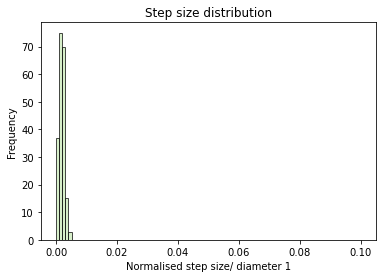

Area of particles 226.1946710584651
Area of box 529
Area fraction 0.4275891702428452


In [150]:
# I want to plot the average step size of particles from frame to frame, normalised by the particle diameter

x_steps = []
y_steps = []
r_steps = []
Diameter1 = 1.2


for particle_id in df_save['particle'].unique():
    particle_data = df_save[df_save['particle'] == particle_id].sort_values('frame')
    x_steps.append(particle_data['x'].diff().dropna().mean()/Diameter1)
    y_steps.append(particle_data['y'].diff().dropna().mean()/Diameter1)
    r_steps.append(np.sqrt(x_steps[-1]**2 + y_steps[-1]**2))

fig, ax = plt.subplots()
# hist with prescribed bins
bins = np.linspace(0, 0.1, 100)
ax.hist(r_steps, bins=bins, color=clrs[0], alpha=0.7, edgecolor='black')

ax.set_xlabel('Normalised step size/ diameter 1')
ax.set_ylabel('Frequency')
ax.set_title('Step size distribution')
plt.show()

Area_Particles = len(df_save['particle'].unique())*np.pi*(Diameter1/2)**2
Area_Box = (box_size-1)**2
print("Area of particles", Area_Particles)
print("Area of box", Area_Box)
print("Area fraction", Area_Particles/Area_Box)


Diffusion 0.2
Sum of forces 1.4540724802646012
Capacity per timestep 1.8175906003307516
Reduction from finite delta t 1.7845542444266445
Length of trajectory 77
Sum of forces in units of 1/gamma 1.4540724802646012


Capacity 1.9641606902282607
Capacity corrected 1.9255814180578812


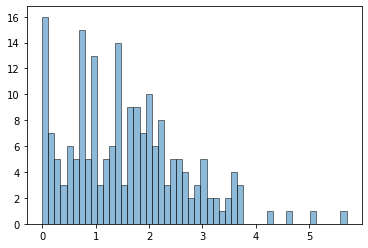

Capacity per particle 1.9641606902282607
number of particles 200
Number of timesteps 77


In [89]:
# get sum of forces over 1 particle trajectory 

particle_data = df_save[df_save['particle'] == 2].sort_values('frame')
sum_forces = particle_data['sumForce'].sum()/len(particle_data)
Diffusion = temperature*gamma  
print("Diffusion",Diffusion)
print("Sum of forces", sum_forces)
Capacity = 1/(4*Diffusion)*sum_forces
print("Capacity per timestep",Capacity)
print("Reduction from finite delta t",Capacity*(1-Capacity*dt*frame))

print("Length of trajectory", len(particle_data))
# in units of 1/gamma
print("Sum of forces in units of 1/gamma", sum_forces/gamma)

#calculate for all particles
sumsum_forces = 0

Diffusion = temperature*gamma
cumm_count = 0
sumsum_forces_arr = []
for particle_id in df_save['particle'].unique():
    particle_data = df_save[df_save['particle'] == particle_id].sort_values('frame')
    sum_forces = particle_data['sumForce'].sum()/len(particle_data)
    #if particle near wall, don't include in sum
    # if np.any(particle_data['x'] < -box_size/2+sigma) or np.any(particle_data['x'] > box_size/2-sigma) or np.any(particle_data['y'] < -box_size/2+sigma) or np.any(particle_data['y'] > box_size/2-sigma):
    #     sumsum_forces+=0
    # else:
    sumsum_forces+=sum_forces
    cumm_count+=1
    sumsum_forces_arr.append(sum_forces)
Capacity = 1/(4*Diffusion)*sumsum_forces/cumm_count
Capacity_corrected = Capacity*(1-Capacity*dt*frame)
print("Capacity",Capacity)
print("Capacity corrected",Capacity_corrected)
fig,ax = plt.subplots()
ax.hist(sumsum_forces_arr,bins=50,alpha = 0.5,edgecolor='black')
plt.show()
print("Capacity per particle",Capacity)
print("number of particles",len(df_save['particle'].unique()))
print("Number of timesteps",len(particle_data))
    

770 steps
Capacity 1.4460659264950992
Capacity corrected 1.425154859857398

770*2 steps
Capacity 1.7739845796306803
Capacity corrected 1.7425143667430059

770 steps after 500 equibbed
Capacity 1.9641606902282607
Capacity corrected 1.9255814180578812


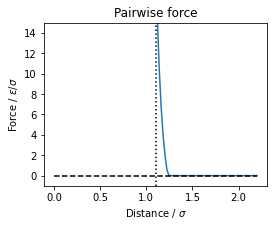

In [58]:
#plot the current pairwise potenital

r_arr = np.linspace(0.1, 2*sigma, 100)
V_arr = []
for r in r_arr:
    V_arr.append(compute_soft_lj_forces_vals(r, epsilon, sigma, rcut, lambda_param))

fig, ax = plt.subplots(1,figsize=(4,3))
ax.plot(r_arr, V_arr)
ax.plot([0,2*sigma],[0,0],linestyle='--',color='black')
ax.plot([sigma,sigma],[-1,15],linestyle=':',color='black')
ax.set_ylim([-1,15])
ax.set_xlabel('Distance / $\sigma$')
ax.set_ylabel('Force / $\epsilon/\sigma$')
ax.set_title('Pairwise force')
plt.show()


